# Machine Problem No.2: Predicting House Prices with Multiple Regression

Dataset Overview:
   Size (sqft)  Bedrooms  Age  Proximity to Downtown (miles)         Price
0         3974         1   97                       2.032719  1.162771e+06
1         1660         5   88                      23.695207  4.900021e+05
2         2094         4   49                       6.440232  6.400737e+05
3         1930         2   28                       8.129315  5.637881e+05
4         1895         1   56                       5.358837  5.651289e+05

Missing Data:
Size (sqft)                      0
Bedrooms                         0
Age                              0
Proximity to Downtown (miles)    0
Price                            0
dtype: int64

Summary Statistics:
       Size (sqft)     Bedrooms          Age  Proximity to Downtown (miles)  \
count  1000.000000  1000.000000  1000.000000                    1000.000000   
mean   2429.857000     2.993000    48.335000                      15.289063   
std     929.914229     1.424423    29.203384                       8.54

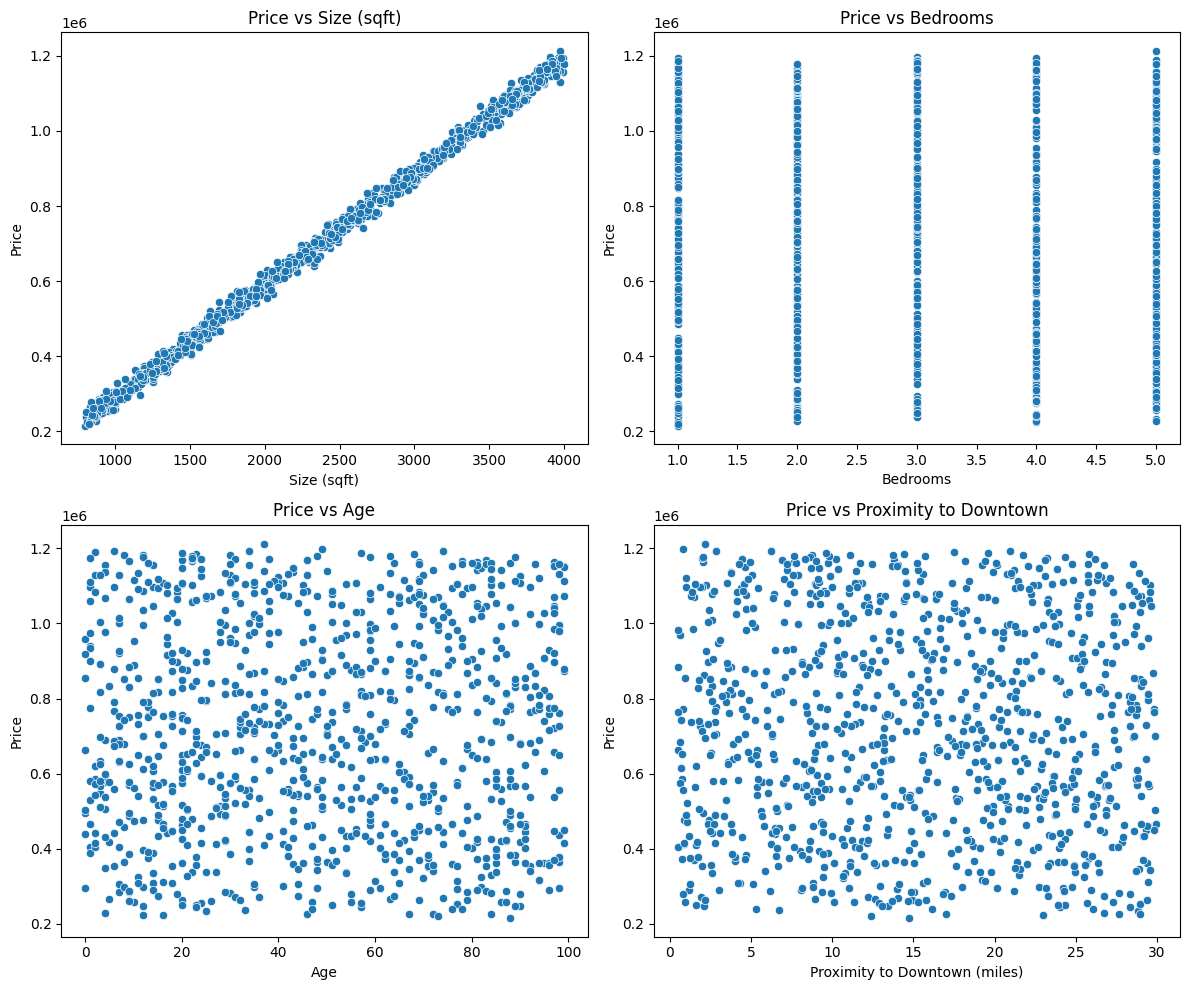

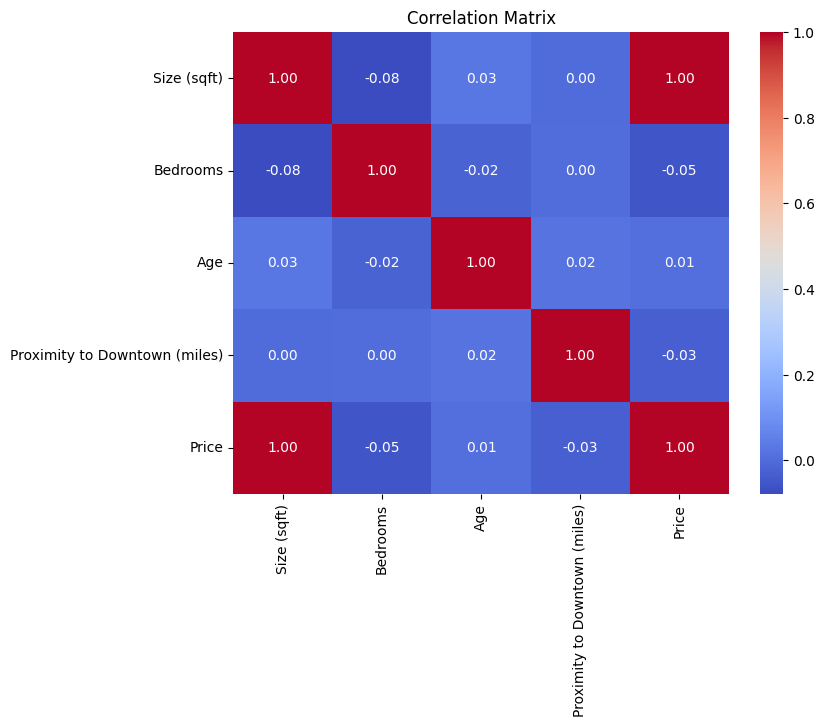

In [1]:
#@title 1. Data Exploration and Visualization

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'datasets_house_prices.csv'
house_data = pd.read_csv(file_path)


print("Dataset Overview:")
print(house_data.head())


print("\nMissing Data:")
print(house_data.isnull().sum())


house_data.fillna(house_data.mean(), inplace=True)

Q1 = house_data.quantile(0.25)
Q3 = house_data.quantile(0.75)
IQR = Q3 - Q1
house_data = house_data[~((house_data < (Q1 - 1.5 * IQR)) | (house_data > (Q3 + 1.5 * IQR))).any(axis=1)]

print("\nSummary Statistics:")
print(house_data.describe())

# Visualizations

# Scatter plots for each feature against Price
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.scatterplot(x='Size (sqft)', y='Price', data=house_data)
plt.title('Price vs Size (sqft)')

plt.subplot(2, 2, 2)
sns.scatterplot(x='Bedrooms', y='Price', data=house_data)
plt.title('Price vs Bedrooms')

plt.subplot(2, 2, 3)
sns.scatterplot(x='Age', y='Price', data=house_data)
plt.title('Price vs Age')

plt.subplot(2, 2, 4)
sns.scatterplot(x='Proximity to Downtown (miles)', y='Price', data=house_data)
plt.title('Price vs Proximity to Downtown')

plt.tight_layout()
plt.show()

# Correlation matrix to analyze relationships between features
plt.figure(figsize=(8, 6))
corr_matrix = house_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [2]:
#@title 2. Data Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features
X = house_data[['Size (sqft)', 'Bedrooms', 'Age', 'Proximity to Downtown (miles)']]
y = house_data['Price']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Output the transformed data
print("First 5 rows of the standardized training data:")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())


First 5 rows of the standardized training data:
   Size (sqft)  Bedrooms       Age  Proximity to Downtown (miles)
0     1.677660 -1.456677  1.737153                       0.045620
1     1.254519  1.403559 -0.577340                      -1.037343
2    -0.817483 -0.741618 -1.130055                      -1.465520
3    -1.143632 -0.026559  0.113553                      -0.051020
4     0.467926 -1.456677  0.389911                       1.465485


In [3]:
#@title 3. Model Development

from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Build the regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train_scaled, y_train)

# Add a constant to the features for the intercept
X_train_const = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_const).fit()

# Print the summary of the OLS regression
print(ols_model.summary())

y_pred = model.predict(X_test_scaled)

# Output the model coefficients and intercept
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.332e+05
Date:                Thu, 09 Jan 2025   Prob (F-statistic):               0.00
Time:                        08:21:12   Log-Likelihood:                -7452.2
No. Observations:                 700   AIC:                         1.491e+04
Df Residuals:                     695   BIC:                         1.494e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.092e+05    385.696   1838.693      0.0

Mean Squared Error (MSE): 100214724.63
R-squared: 1.00
Adjusted R-squared: 1.00


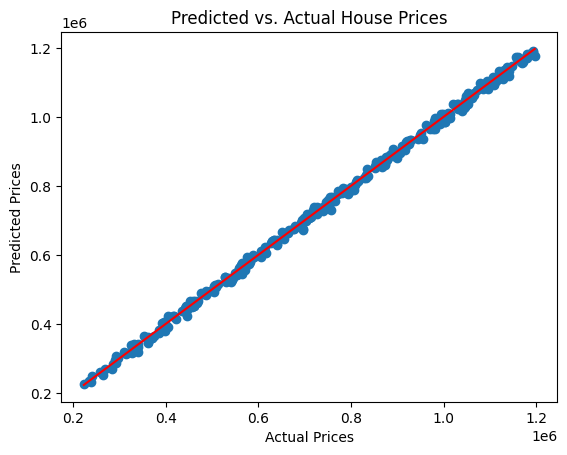

In [4]:
#@title 4. Model Evaluation

from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Calculate R-squared and Adjusted R-squared
r_squared = r2_score(y_test, y_pred)
n = X_test_scaled.shape[0]
p = X_test_scaled.shape[1]
adjusted_r_squared = 1 - (1 - r_squared) * ((n - 1) / (n - p - 1))

print(f"R-squared: {r_squared:.2f}")
print(f"Adjusted R-squared: {adjusted_r_squared:.2f}")

# Plot Predicted vs. Actual Prices
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs. Actual House Prices")
plt.show()